## Football Player Performance Insights

##### The project examines football player attributes to identify trends affecting skill level and market worth.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset overview

##### The dataset contains 18,207 records of professional football players across multiple countries, including personal details, physical attributes, performance ratings, club information, salary, and market valuation.

In [2]:
# loading dataset
df = pd.read_csv('dataset_jasleen.csv')

In [3]:
df.head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500.0,565.0,Left,5.0,4.0,RF,2004,2021-01-01,5.583333,159.0,226500.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000.0,405.0,Right,5.0,5.0,ST,2018,2022-01-01,6.166667,183.0,127100.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.0,290.0,Right,5.0,5.0,LW,2017,2022-01-01,5.750000,150.0,228100.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,1.0,GK,2011,2020-01-01,6.333333,168.0,138600.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000.0,355.0,Right,4.0,4.0,RCM,2015,2023-01-01,5.916667,154.0,196400.0


In [4]:
df.tail()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
18202,238813,J. Lundstram,19,England,47,65,Crewe Alexandra,60.0,1.0,Right,1.0,2.0,CM,2017,2019-01-01,5.750000,134.0,143.0
18203,243165,N. Christoffersson,19,Sweden,47,63,Trelleborgs FF,60.0,1.0,Right,1.0,2.0,ST,2018,2020-01-01,6.250000,170.0,113.0
18204,241638,B. Worman,16,England,47,67,Cambridge United,60.0,1.0,Right,1.0,2.0,ST,2017,2021-01-01,5.666667,148.0,165.0
18205,246268,D. Walker-Rice,17,England,47,66,Tranmere Rovers,60.0,1.0,Right,1.0,2.0,RW,2018,2019-01-01,5.833333,154.0,143.0
18206,246269,G. Nugent,16,England,46,66,Tranmere Rovers,60.0,1.0,Right,1.0,2.0,CM,2018,2019-01-01,5.833333,176.0,165.0


In [5]:
df.shape

(18207, 18)

In [6]:
df.columns

Index(['ID', 'Name', 'Age', 'Nationality', 'Overall', 'Potential', 'Club',
       'Value', 'Wage', 'Preferred Foot', 'International Reputation',
       'Skill Moves', 'Position', 'Joined', 'Contract Valid Until', 'Height',
       'Weight', 'Release Clause'],
      dtype='str')

In [7]:
df.columns = df.columns.str.strip()

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        18207 non-null  int64  
 1   Name                      18207 non-null  str    
 2   Age                       18207 non-null  int64  
 3   Nationality               18207 non-null  str    
 4   Overall                   18207 non-null  int64  
 5   Potential                 18207 non-null  int64  
 6   Club                      17966 non-null  str    
 7   Value                     17955 non-null  float64
 8   Wage                      18207 non-null  float64
 9   Preferred Foot            18207 non-null  str    
 10  International Reputation  18159 non-null  float64
 11  Skill Moves               18159 non-null  float64
 12  Position                  18207 non-null  str    
 13  Joined                    18207 non-null  int64  
 14  Contract Valid Un

In [9]:
df.describe()

,ID,Age,Overall,Potential,Value,Wage,International Reputation,Skill Moves,Joined,Height,Weight,Release Clause
count,18207.000000,18207.000000,18207.000000,18207.000000,17955.000000,18207.000000,18159.000000,18159.000000,18207.000000,18207.000000,18207.000000,18207.000000
mean,214298.338606,25.122206,66.238699,71.307299,2444.530214,9.731312,1.113222,2.361308,2016.420607,5.946771,165.979129,4585.060971
std,29965.244204,4.669943,6.908930,6.136496,5626.715434,21.999290,0.394031,0.756164,2.018194,0.220514,15.572775,10630.414430
min,16.000000,16.000000,46.000000,48.000000,10.000000,0.000000,1.000000,1.000000,1991.000000,5.083333,110.000000,13.000000
25%,200315.500000,21.000000,62.000000,67.000000,325.000000,1.000000,1.000000,2.000000,2016.000000,5.750000,154.000000,570.000000
50%,221759.000000,25.000000,66.000000,71.000000,700.000000,3.000000,1.000000,2.000000,2017.000000,5.916667,165.000000,1300.000000
75%,236529.500000,28.000000,71.000000,75.000000,2100.000000,9.000000,1.000000,3.000000,2018.000000,6.083333,176.000000,4585.060806
max,246620.000000,45.000000,94.000000,95.000000,118500.000000,565.000000,5.000000,5.000000,2018.000000,6.750000,243.000000,228100.000000


##### The data overview reveals that the dataset is large, well-structured, and contains both numerical and categorical features, with some missing values requiring preprocessing.

### Data Cleaning and Preprocessing

In [10]:
#Checking missing values
df.isnull().sum()

ID                            0
Name                          0
Age                           0
Nationality                   0
Overall                       0
Potential                     0
Club                        241
Value                       252
Wage                          0
Preferred Foot                0
International Reputation     48
Skill Moves                  48
Position                      0
Joined                        0
Contract Valid Until        289
Height                        0
Weight                        0
Release Clause                0
dtype: int64

In [11]:
# Handling missing values

# Fill missing categorical values
df['Club'] = df['Club'].fillna('Unknown')

# Fill missing numerical values using median
df['Value'] = df['Value'].fillna(df['Value'].median())
df['International Reputation'] = df['International Reputation'].fillna(df['International Reputation'].median())
df['Skill Moves'] = df['Skill Moves'].fillna(df['Skill Moves'].median())

# Fill missing contract dates using forward fill
df['Contract Valid Until'] = df['Contract Valid Until'].ffill()

In [32]:
df.isnull().sum()

ID                          0
Name                        0
Age                         0
Nationality                 0
Overall                     0
Potential                   0
Club                        0
Value                       0
Wage                        0
Preferred Foot              0
International Reputation    0
Skill Moves                 0
Position                    0
Contract Valid Until        0
Height                      0
Weight                      0
Release Clause              0
dtype: int64

In [12]:
#Checking for duplicate values 
df.duplicated().sum()

np.int64(0)

In [13]:
# Convert categorical columns to category type
cat_cols = ['Name', 'Nationality', 'Club', 'Preferred Foot', 'Position']
for col in cat_cols:
    df[col] = df[col].astype('category')

##### Data cleaning and preprocessing were performed to handle missing values, standardize categorical features,  and check duplicates to ensure high-quality and reliable analysis

### Correlation Analysis

In [14]:
# Selecting numerical columns 
num_cols = [
    'Age', 'Overall', 'Potential', 'Value', 'Wage',
    'International Reputation', 'Skill Moves',
    'Height', 'Weight', 'Release Clause', 'Joined'
]

df_corr = df[num_cols]

In [15]:
corr_matrix = df_corr.corr()
corr_matrix

,Age,Overall,Potential,Value,Wage,International Reputation,Skill Moves,Height,Weight,Release Clause,Joined
Age,1.000000,0.452350,-0.253312,0.075780,0.141145,0.253457,0.027641,0.082506,0.229940,0.058672,-0.202658
Overall,0.452350,1.000000,0.660939,0.627674,0.571926,0.499654,0.414906,0.038527,0.154557,0.597821,-0.169281
Potential,-0.253312,0.660939,1.000000,0.576267,0.486413,0.372887,0.354516,-0.009791,-0.006935,0.562346,-0.047661
Value,0.075780,0.627674,0.576267,1.000000,0.858236,0.653537,0.315885,0.002722,0.046081,0.972663,-0.114298
Wage,0.141145,0.571926,0.486413,0.858236,1.000000,0.668719,0.263540,0.019638,0.064764,0.828161,-0.142337
International Reputation,0.253457,0.499654,0.372887,0.653537,0.668719,1.000000,0.208429,0.034877,0.088331,0.620795,-0.132829
Skill Moves,0.027641,0.414906,0.354516,0.315885,0.263540,0.208429,1.000000,-0.422626,-0.351104,0.297381,0.020947
Height,0.082506,0.038527,-0.009791,0.002722,0.019638,0.034877,-0.422626,1.000000,0.754678,0.001835,0.001188
Weight,0.229940,0.154557,-0.006935,0.046081,0.064764,0.088331,-0.351104,0.754678,1.000000,0.038103,-0.028274
Release Clause,0.058672,0.597821,0.562346,0.972663,0.828161,0.620795,0.297381,0.001835,0.038103,1.000000,-0.115374


In [16]:
df_corr.corr()['Overall'].sort_values(ascending=False)

Overall                     1.000000
Potential                   0.660939
Value                       0.627674
Release Clause              0.597821
Wage                        0.571926
International Reputation    0.499654
Age                         0.452350
Skill Moves                 0.414906
Weight                      0.154557
Height                      0.038527
Joined                     -0.169281
Name: Overall, dtype: float64

In [17]:
df_corr.corr()['Value'].sort_values(ascending=False)

Value                       1.000000
Release Clause              0.972663
Wage                        0.858236
International Reputation    0.653537
Overall                     0.627674
Potential                   0.576267
Skill Moves                 0.315885
Age                         0.075780
Weight                      0.046081
Height                      0.002722
Joined                     -0.114298
Name: Value, dtype: float64

In [18]:
df_corr.corr()['Wage'].sort_values(ascending=False)

Wage                        1.000000
Value                       0.858236
Release Clause              0.828161
International Reputation    0.668719
Overall                     0.571926
Potential                   0.486413
Skill Moves                 0.263540
Age                         0.141145
Weight                      0.064764
Height                      0.019638
Joined                     -0.142337
Name: Wage, dtype: float64

##### Correlation analysis highlights the key relationships among player attributes, identifying the main drivers of performance, salary, and market valuation.

### Time Series Analysis

In [19]:
# Converts Joined into datetime format
df['Joined'] = pd.to_datetime(df['Joined'], format='%Y', errors='coerce')

# Converts Contract Valid Until into datetime format
df['Contract Valid Until'] = pd.to_datetime(df['Contract Valid Until'], errors='coerce')

In [20]:
# Sort data based on Joined date
df = df.sort_values(by='Joined')

In [21]:
# Makes Joined column the dataframe index
df.set_index('Joined', inplace=True)

In [22]:
# Year-wise Player Joining Trend
players_per_year = df.resample('YE').size()
players_per_year

Joined
1991-12-31       1
1992-12-31       0
1993-12-31       0
1994-12-31       0
1995-12-31       0
1996-12-31       0
1997-12-31       0
1998-12-31       3
1999-12-31       1
2000-12-31       2
2001-12-31       2
2002-12-31      10
2003-12-31      13
2004-12-31      12
2005-12-31      17
2006-12-31      18
2007-12-31      38
2008-12-31      53
2009-12-31      78
2010-12-31     131
2011-12-31     201
2012-12-31     340
2013-12-31     458
2014-12-31     818
2015-12-31    1336
2016-12-31    3799
2017-12-31    4307
2018-12-31    6569
Freq: YE-DEC, dtype: int64

In [23]:
# Contract Expiry Trend Over Time
contract_expiry = df['Contract Valid Until'].dt.year.value_counts().sort_index()
contract_expiry

Contract Valid Until
2018    1050
2019    5996
2020    4095
2021    4470
2022    1503
2023    1061
2024      23
2025       7
2026       2
Name: count, dtype: int64

##### Time series analysis using joining and contract expiry dates highlights trends in player recruitment and contract lifecycle patterns over time.

### Outliers Detection

In [9]:
num_cols = [
    'Age', 'Overall', 'Potential', 'Value', 'Wage',
    'International Reputation', 'Skill Moves',
    'Height', 'Weight', 'Release Clause'
]

In [ ]:
# Detect Outliers using IQR Method
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) |
            (df[num_cols] > (Q3 + 1.5 * IQR)))

outlier_count = outliers.sum()
outlier_count

Age                           47
Overall                      163
Potential                    160
Value                       2420
Wage                        2031
International Reputation    1627
Skill Moves                   51
Height                        41
Weight                        75
Release Clause              1866
dtype: int64

In [14]:
# Total Rows Containing Outliers
total_outlier_rows = outliers.any(axis=1).sum()
total_outlier_rows

np.int64(3515)

In [15]:
# Remove Outliers
df_clean = df[~outliers.any(axis=1)].copy()
print("Original Shape:", df.shape)
print("After Outlier Removal:", df_clean.shape)

Original Shape: (18207, 19)
After Outlier Removal: (14692, 19)


##### Outliers were detected using the IQR method and removed to improve data consistency and ensure reliable statistical analysis.


### Visualization

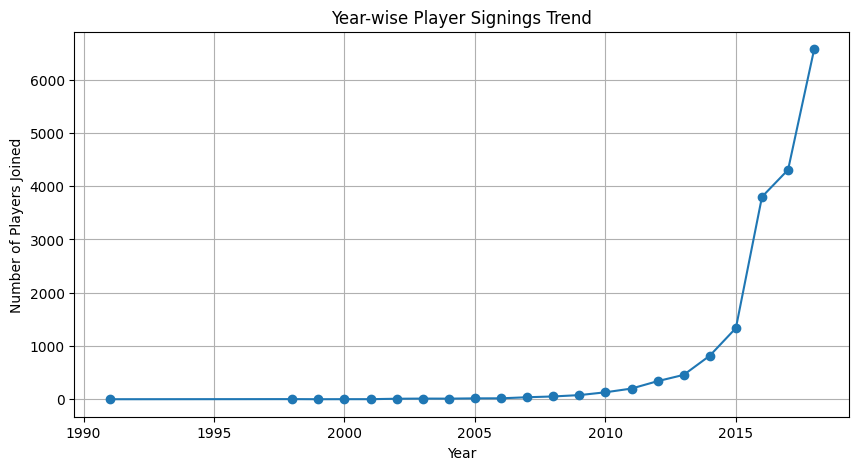

In [22]:
# Year-wise Player Joining Trend
plt.figure(figsize=(10,5))
df.groupby(df['Joined'].dt.year).size().plot(marker='o')
plt.title("Year-wise Player Signings Trend")
plt.xlabel("Year")
plt.ylabel("Number of Players Joined")
plt.grid(True)
plt.show()

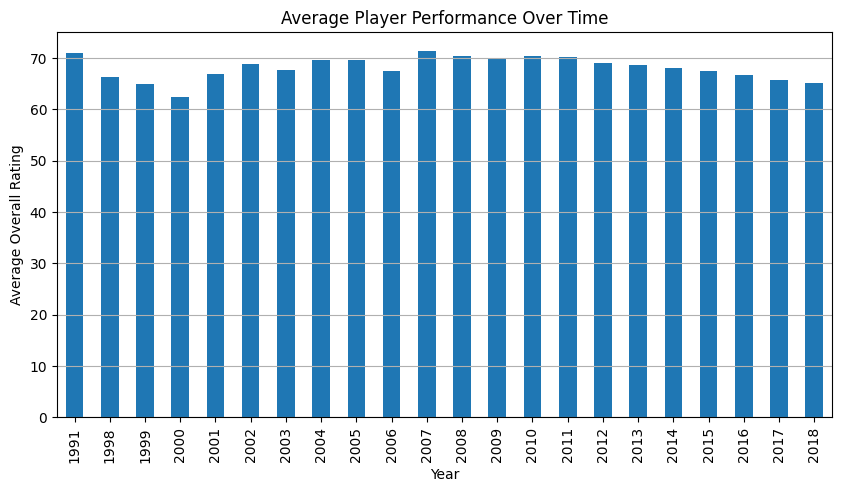

In [24]:
# Trend of Average Overall Rating Over Years
yearly_overall = df.groupby(df['Joined'].dt.year)['Overall'].mean()

plt.figure(figsize=(10,5))
yearly_overall.plot(kind='bar')
plt.title("Average Player Performance Over Time")
plt.xlabel("Year")
plt.ylabel("Average Overall Rating")
plt.grid(axis='y')
plt.show()

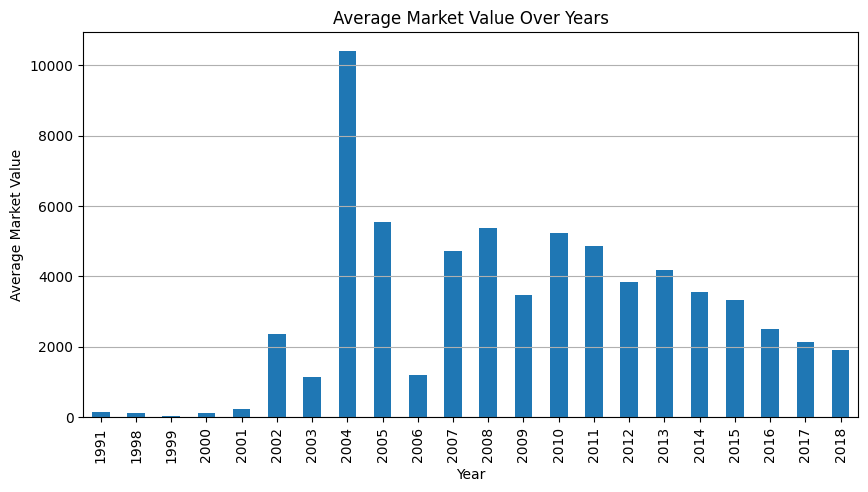

In [ ]:
# Market Value Trend Over Time
yearly_value = df.groupby(df['Joined'].dt.year)['Value'].mean()

plt.figure(figsize=(10,5))
yearly_value.plot(kind='bar')
plt.title("Average Market Value Over Years")
plt.xlabel("Year")
plt.ylabel("Average Market Value")
plt.grid(axis='y')
plt.show()

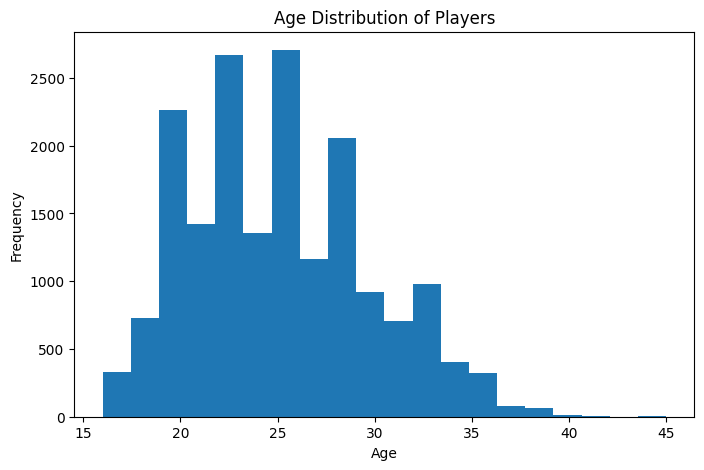

In [29]:
# Age distribution
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution of Players")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

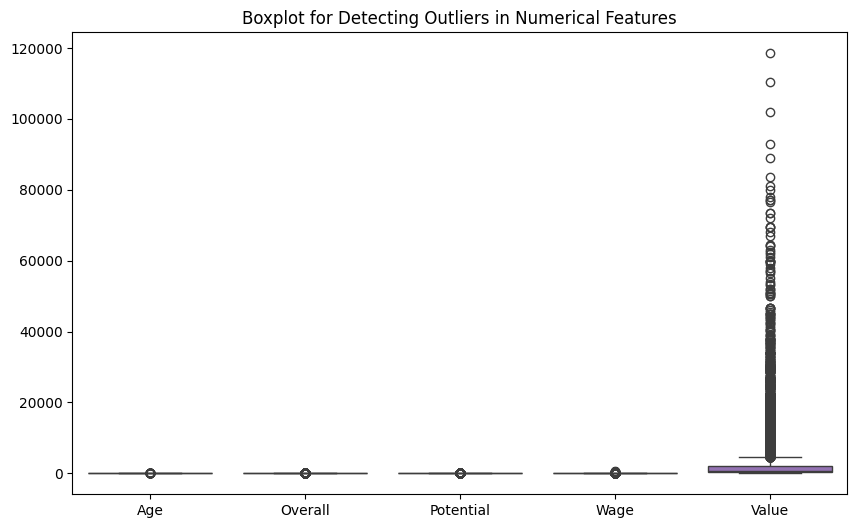

In [27]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['Age','Overall','Potential','Wage','Value']])
plt.title('Boxplot for Detecting Outliers in Numerical Features')
plt.show()

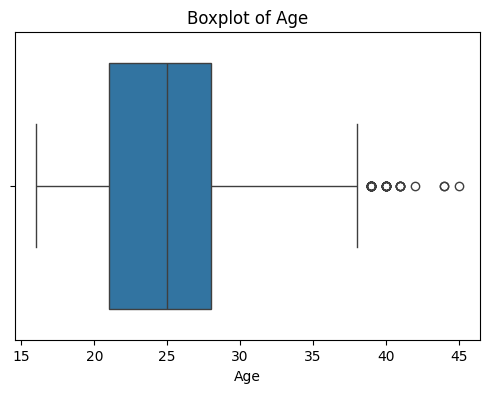

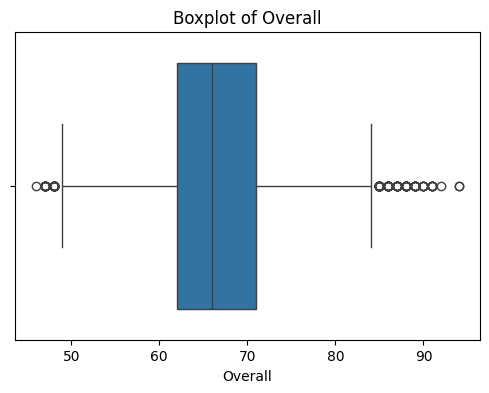

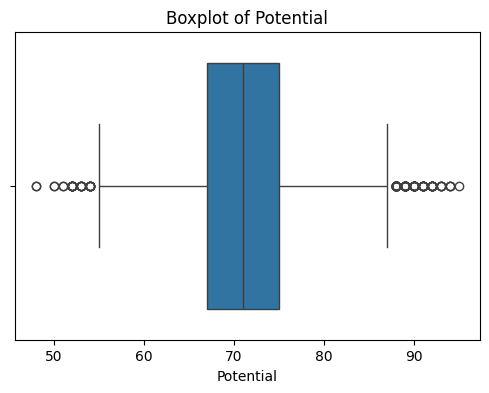

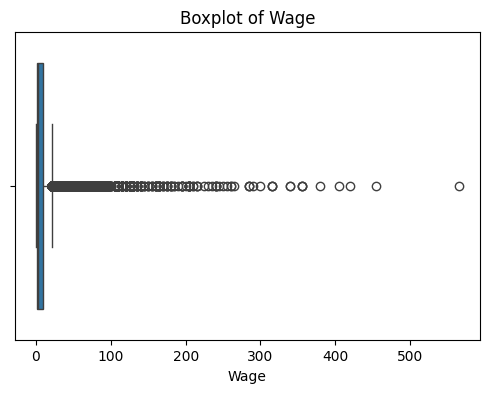

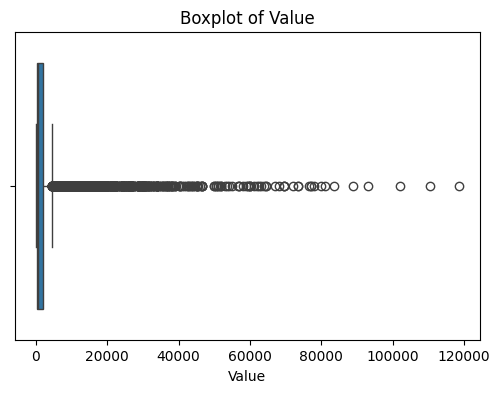

In [31]:
cols = ['Age','Overall','Potential','Wage','Value']

for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

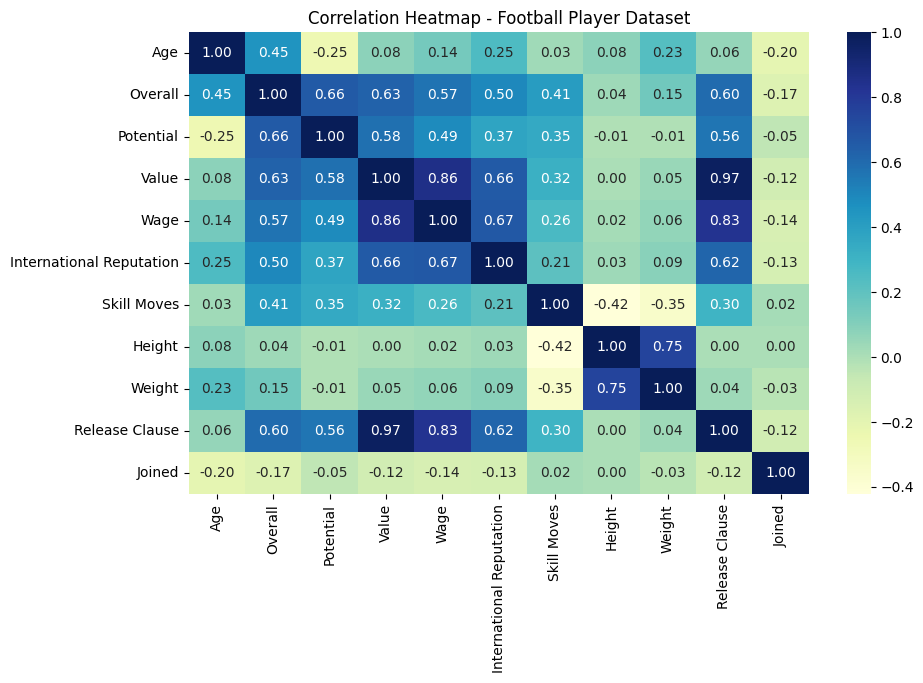

In [31]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Correlation Heatmap - Football Player Dataset")
plt.show()

##### Visualization techniques were applied to explore distributions, patterns, and relationships among key player attributes.

### Statistical Insights 

In [27]:
cols = ['Age', 'Overall', 'Potential', 'Value', 'Wage', 'Height', 'Weight']

stats = pd.DataFrame({
    'Mean': df[cols].mean(),
    'Median': df[cols].median(),
    'Mode': df[cols].mode().iloc[0]
})

stats

,Mean,Median,Mode
Age,25.122206,25.000000,21.0
Overall,66.238699,66.000000,66.0
Potential,71.307299,71.000000,70.0
Value,2444.530214,700.000000,1100.0
Wage,9.731312,3.000000,1.0
Height,5.946771,5.916667,6.0
Weight,165.979129,165.000000,165.0


##### Mean, median, and mode were computed to understand the central tendency and typical values of key player attributes.

### Business Insights

##### Players with higher **overall ratings and potential** tend to have significantly higher **market value and wages**, indicating that performance is the primary driver of player valuation.
##### **Younger players generally show higher potential**, making them valuable long-term investments for clubs aiming to develop future star players.
##### The strong relationship between **market value, wages, and release clauses** suggests that clubs price contracts based on expected player performance and transfer demand.
##### Contract duration analysis suggests that clubs often prefer **short to medium-term contracts**, allowing flexibility for transfers, renewals, and squad restructuring.
##### Physical attributes such as **height and weight have minimal impact on market value**, meaning technical ability and performance metrics are more important in player evaluation.
##### Data analysis like this can help clubs improve **player scouting, salary planning, contract negotiations, and long-term squad development strategies.**


### Conclusion

##### The analysis shows that player performance and potential are the key factors influencing market value, wages, and contract decisions in professional football.